In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
#sys.path.insert(0, r"C:\SVN\achapkowski_geosaurus_fork_issue_3367\src")
import arcgis
arcgis.__file__
from datetime import datetime
from arcgis.features import FeatureCollection
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob


In [3]:
from arcgis.gis import GIS
#gis = GIS(profile="your_online_profile")
gis = GIS("https://deldev.maps.arcgis.com", "demos_deldev", "DelDevs12")

In [4]:
from arcgis.features.find_locations import create_watersheds

In [5]:
"""The original item not loadable -
"This item is not currently available. The ArcGIS Online subscription associated with this item has been cancelled."
"""
# chennai_lakes = gis.content.get('b98100970c744824b227a5e1ccd113c1') 

<Item title:"chennai_lakes" type:Feature Layer Collection owner:lizgraham_gp2>
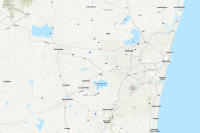

In [9]:
chennai_lakes = gis.content.get('5dce39f176e644e18ee6eb3b48314456')
chennai_lakes

In [10]:
lakes_lyr = chennai_lakes.layers[0]

In [11]:
from datetime import datetime
lakes_watersheds_test1 = create_watersheds(lakes_lyr,
                                           output_name='create_watersheds test 01'  + str(datetime.now().microsecond),
                                          future=True)

In [12]:
lakes_watersheds_test1.task

'CreateWatersheds'

In [13]:
assert isinstance(lakes_watersheds_test1.result(), Item)
lakes_watersheds_test1.result()

<Item title:"create_watersheds test 01258992" type:Feature Layer Collection owner:demos_deldev>

In [14]:
lakes_watersheds_test1.result().delete()

True

In [15]:
lakes_watershed_test2 = create_watersheds(lakes_lyr,
                                          source_database='90m',
                                          output_name='create watersheds test 02' + str(datetime.now().microsecond),
                                         future=True)

In [16]:
lakes_watershed_test2

<CreateWatersheds GP Job: jfc77f565601d4c00b4bb593fc701d053>

In [17]:
lakes_watershed_test2.result().delete()

True

In [18]:
lakes_watershed_test2b = create_watersheds(lakes_lyr,
                                          source_database='90m',
                                          future=True)
lakes_watershed_test2b.task

'CreateWatersheds'

In [19]:
lakes_watershed_test2b.result()

{'snap_pour_pts_layer': <FeatureCollection>,
 'watershed_layer': <FeatureCollection>}

In [20]:
assert isinstance(lakes_watershed_test2b.result(), dict)

In [21]:
lakes_watershed_test2c = create_watersheds(lakes_lyr,
                                          source_database='90m')
assert isinstance(lakes_watershed_test2c, dict)

In [22]:
lakes_watershed_test2c

{'snap_pour_pts_layer': <FeatureCollection>,
 'watershed_layer': <FeatureCollection>}

In [23]:
lakes_watershed_test3 = create_watersheds(lakes_lyr,
                                          search_distance=36,
                                          search_units='Meters',
                                          source_database='90m',
                                          output_name='create watersheds test 03' + str(datetime.now().microsecond))

In [24]:
assert isinstance(lakes_watershed_test3, Item)
lakes_watershed_test3

<Item title:"create watersheds test 03542920" type:Feature Layer Collection owner:demos_deldev>

In [25]:
lakes_watershed_test3.delete()

True